In [1]:
# import libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

In [2]:
# parameters
img_size = 224
batch_size = 32
epochs = 10

In [3]:

train_path = "Brain-Tumor-Classification-DataSet-master/Training"
test_path = "Brain-Tumor-Classification-DataSet-master/Testing"

# data preprocessing
datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical"
)

test_data = datagen.flow_from_directory(
    test_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical"
)

print(train_data.class_indices)

# build cnn model
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation="relu"))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation="relu"))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation="relu"))

model.add(layers.Dense(4,activation="softmax"))

model.summary()

Found 2870 images belonging to 4 classes.
Found 352 images belonging to 4 classes.
{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


c:\Users\bhard\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:


# compile model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# train model
history = model.fit(
    train_data,
    epochs=epochs,
    validation_data=test_data
)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 82s 885ms/step - accuracy: 0.6237 - loss: 0.8841 - val_accuracy: 0.4744 - val_loss: 2.0235
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 66s 733ms/step - accuracy: 0.8195 - loss: 0.4687 - val_accuracy: 0.6023 - val_loss: 2.1436
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 63s 701ms/step - accuracy: 0.9105 - loss: 0.2416 - val_accuracy: 0.6477 - val_loss: 2.1384
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 60s 668ms/step - accuracy: 0.9519 - loss: 0.1450 - val_accuracy: 0.6733 - val_loss: 3.6187
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 62s 690ms/step - accuracy: 0.9777 - loss: 0.0647 - val_accuracy: 0.7244 - val_loss: 4.1673
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 90s 997ms/step - accuracy: 0.9798 - loss: 0.0613 - val_accuracy: 0.6420 - val_loss: 4.3182
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 119s 734ms/step - accuracy: 0.9909 - loss: 0.0291 - val_accuracy: 0.6960 - val_loss: 5.1160
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 59s 648ms/step - accuracy: 0.9906 - loss: 0.0270 - val_acc

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.6960 - loss: 6.3174
Test Accuracy: 0.6960227489471436


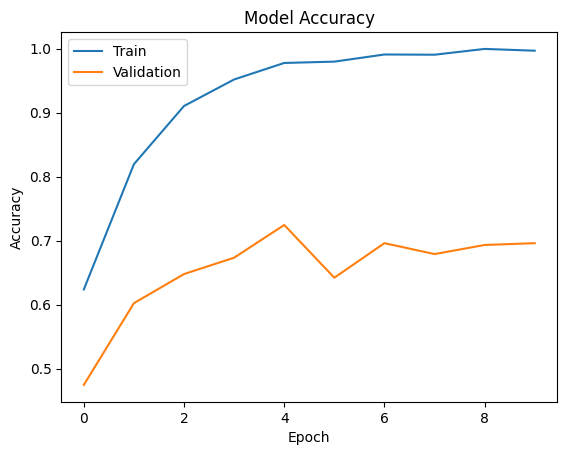

In [7]:
# evaluate model
loss, accuracy = model.evaluate(test_data)
print("Test Accuracy:", accuracy)

# plot accuracy
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])
plt.show()


In [8]:
# predict tumor type
img_path = "test_image.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array/255.0
img_array = np.expand_dims(img_array,axis=0)

prediction = model.predict(img_array)

classes = ["Glioma Tumor","Meningioma Tumor","No Tumor","Pituitary Tumor"]

result = classes[np.argmax(prediction)]

print("Prediction:", result)

if result == "No Tumor":
    print("Brain is Normal")
else:
    print("Tumor Detected:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Prediction: Meningioma Tumor
Tumor Detected: Meningioma Tumor
